In [3]:
# ═══════════════════════════════════════════════════════════
# 이 셀의 역할: Unsloth 및 학습에 필요한 패키지 설치
# - unsloth: 최적화된 LLM 파인튜닝 프레임워크
# - peft: LoRA 등 PEFT 기법 제공
# - trl: SFTTrainer(지도 학습 미세조정 트레이너)
# - datasets: HuggingFace 데이터셋 로딩
# ═══════════════════════════════════════════════════════════

!pip install -q unsloth
!pip install -q --upgrade typing_extensions
!pip install -q \
    transformers>=4.55.0 peft>=0.10.0 trl>=0.8.0 \
    datasets>=3.0.0 accelerate>=0.30.0 bitsandbytes>=0.43.0 tokenizers>=0.20.0

In [4]:
from unsloth import FastModel
import torch
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════
# 이 셀의 핵심: Unsloth로 4-bit 양자화 모델을 로딩
#
# [이 셀에서 하는 것]
# Gemma-3-1B 모델을 NF4(4-bit) 양자화 상태로 GPU에 로딩한다.
# 5-2에서 BitsAndBytesConfig를 직접 설정했던 것을
# Unsloth는 FastModel.from_pretrained() 한 줄로 처리한다.
#
# [모델 이름 해석]
# 'unsloth/gemma-3-1b-it-unsloth-bnb-4bit'
#  ├─ unsloth/     → Unsloth가 최적화한 버전
#  ├─ gemma-3      → Google의 Gemma 3세대
#  ├─ 1b           → 10억(1 Billion) 파라미터
#  ├─ it           → Instruction-Tuned (대화형으로 사전학습됨)
#  └─ bnb-4bit     → bitsandbytes 4-bit 양자화 적용
#
# [5-2 연결]
# load_in_4bit=True → 5-2에서 배운 NF4 양자화가 적용된다.
# 5-2에서는 "추론용"으로 양자화했지만,
# 여기서는 "학습의 베이스 모델"로 양자화를 사용한다.
#
# [확인 포인트]
# GPU 메모리가 ~1GB 수준으로 나오면 정상이다.
# 4-bit 양자화 덕분에 10억 파라미터 모델이 ~1GB에 로딩된다.
# (FP16이라면 ~2GB, FP32라면 ~4GB가 필요했을 것이다.)
# ═══════════════════════════════════════════════════════════

max_seq_length = 1024  # 시퀀스 최대 길이 (메모리 효율을 위해 제한)

# ★ 핵심: 4-bit 양자화 모델 로딩 (Unsloth가 내부적으로 NF4 설정)
model, tokenizer = FastModel.from_pretrained(
    model_name='unsloth/gemma-3-1b-it-unsloth-bnb-4bit',
    max_seq_length=max_seq_length,
    load_in_4bit=True,   # ← 5-2에서 배운 INT4/NF4 양자화!
)

print(f'모델 로딩 완료: Gemma-3-1B (4-bit 양자화)')
if torch.cuda.is_available():
    mem = torch.cuda.memory_allocated() / 1024**3
    print(f'GPU 메모리: {mem:.2f} GB')
    print(f'→ 10억 파라미터 모델이 4-bit 양자화 덕분에 ~1GB에 로딩되었다.')


==((====))==  Unsloth 2026.3.11: Fast Gemma3 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA GeForce RTX 5060 Ti. Num GPUs = 1. Max memory: 15.928 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

모델 로딩 완료: Gemma-3-1B (4-bit 양자화)
GPU 메모리: 1.87 GB
→ 10억 파라미터 모델이 4-bit 양자화 덕분에 ~1GB에 로딩되었다.


# Parameter Efficient Fine Tuning

In [5]:
# ═══════════════════════════════════════════════════════════
# 이 셀의 핵심: Fine-tuning "전" 베이스 모델의 답변을 기록 (Before)
#
# [이 셀에서 하는 것]
# 체스 기보를 입력했을 때 학습 전 모델이 어떤 답변을 하는지 확인한다.
# 이 결과를 response_before에 저장해 두고,
# 마지막 셀에서 학습 후 결과(After)와 비교한다.
#
# [확인 포인트]
# 학습 전 모델은 체스 전문 지식이 없으므로:
# - "a6" 같은 정확한 수를 예측하지 못하고
# - 체스에 대한 일반적인 설명이나 엉뚱한 답변을 할 가능성이 높다.
# 이것이 "Fine-tuning이 왜 필요한가"의 직접적 증거이다.
#
# [체스 기보 해설]
# "1. e4 e5 2. Nf3 Nc6 3. Bb5" = Ruy Lopez Opening(루이 로페스)
# 이 기보의 정답(흑의 최선 수): a6 (Morphy Defense)
# ═══════════════════════════════════════════════════════════

# 테스트 입력: Ruy Lopez Opening
test_input = '1. e4 e5 2. Nf3 Nc6 3. Bb5'

messages = [
    {'role': 'user', 'content': f'Predict the next best move: {test_input}'}
]

# apply_chat_template: Gemma-3의 대화 형식으로 변환
# add_generation_prompt=True → 모델이 답변을 생성하도록 유도
text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)

# 추론 실행
inputs = tokenizer(text, return_tensors='pt').to('cuda')
with torch.no_grad():  # 추론 시 그래디언트 계산 불필요
    outputs = model.generate(**inputs, max_new_tokens=50, do_sample=False)

# 응답 추출 (입력 부분 제외, 새로 생성된 토큰만)
response_before = tokenizer.decode(
    outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
)

print(f'입력 기보: {test_input}')
print(f'(해설: Ruy Lopez Opening — 흑의 최선 수는 a6)')
print(f'\n학습 전 응답: {response_before[:200]}')
print(f'\n→ 체스 전문 지식 없이 범용적인 답변을 하는 것을 확인하라.')
print(f'  Fine-tuning 후 이 답변이 "a6"으로 바뀌는지 마지막에 비교한다.')

Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


입력 기보: 1. e4 e5 2. Nf3 Nc6 3. Bb5
(해설: Ruy Lopez Opening — 흑의 최선 수는 a6)

학습 전 응답: The most common and generally considered best move for Black is **Be3**.

Here's why and a breakdown of the position:

* **Why Be3 is good:**
    * **Controls the center:** Be3 immediately challenges 

→ 체스 전문 지식 없이 범용적인 답변을 하는 것을 확인하라.
  Fine-tuning 후 이 답변이 "a6"으로 바뀌는지 마지막에 비교한다.



🔥 Full Fine-tuning이 왜 어려운가?
📊 7B 모델 기준 비트별 메모리 사용량
FP32 (32-bit)        → 26.08 GB
FP16/BF16 (16-bit)   → 13.04 GB
INT8 (8-bit)         → 6.52 GB
NF4 (4-bit)          → 3.26 GB


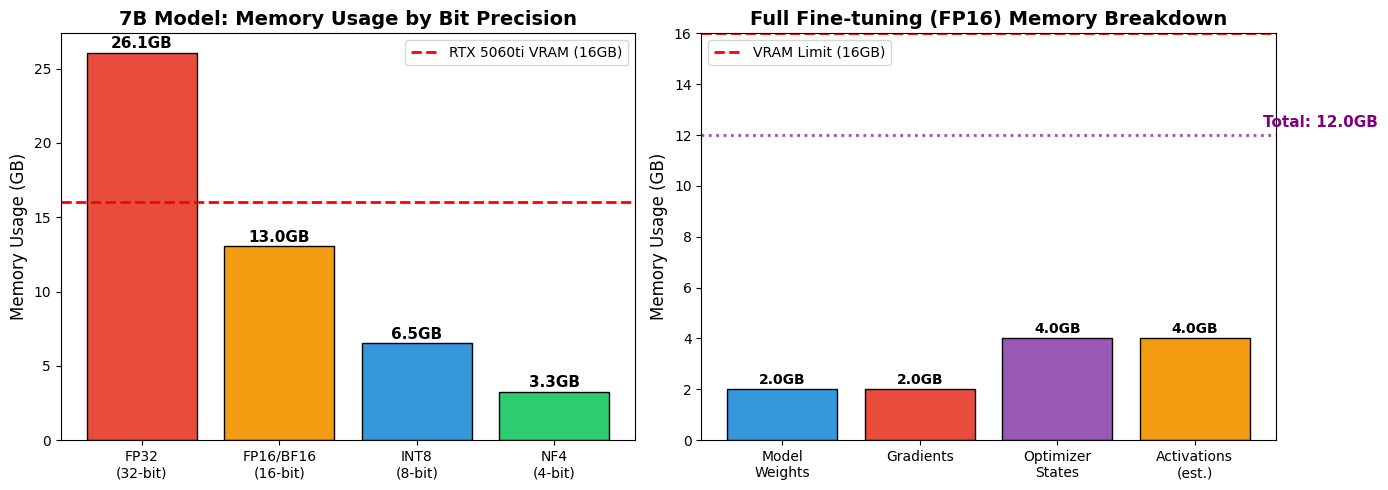


📊 현재 모델 (0.66B params) Full FT 메모리 분석
  • 모델 가중치 (FP16):     1.23 GB
  • Gradient (FP16):        1.23 GB
  • Optimizer States (FP32): 4.94 GB
  • Activations (추정):     2.47 GB
  ─────────────────────────────────
  • 총 필요 메모리:         9.88 GB

  💡 현재 모델(0.66B)은 16GB에 들어갈 수 있지만,
     7B 모델은 약 69GB가 필요하여 사실상 불가능합니다!
  ❌ 또한 현재 4-bit 양자화 모델은 gradient 계산 자체가 불가능합니다!
  ✅ 해결책: PEFT (LoRA) + 4-bit 양자화 = QLoRA

⚠️ 참고: 현재 로드된 모델은 4-bit 양자화 모델입니다
  • 4-bit 양자화 가중치는 gradient 계산이 불가능합니다.
  • requires_grad=True 설정 시 RuntimeError 발생
  • 이것이 바로 QLoRA가 LoRA adapter만 학습하는 이유입니다!
  • Base model(4-bit)은 고정 ❄️, LoRA adapter(FP16)만 학습 🔥


In [9]:
# TODO: Full Fine-tuning 메모리 요구량 계산 및 시각화

import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 📊 비트 정밀도별 메모리 사용량 비교
# =====================================================
# 왜 4-bit 양자화가 필요한지 숫자로 명확히 이해합니다.

def compare_precision_memory(num_params=7_000_000_000):
    """7B 파라미터 모델 기준 비트별 메모리 비교"""
    precisions = {
        'FP32\n(32-bit)': 4.0,      # 4 bytes/param
        'FP16/BF16\n(16-bit)': 2.0, # 2 bytes/param
        'INT8\n(8-bit)': 1.0,       # 1 byte/param
        'NF4\n(4-bit)': 0.5,        # 0.5 bytes/param
    }
    
    print("=" * 60)
    print("📊 7B 모델 기준 비트별 메모리 사용량")
    print("=" * 60)
    
    memories = []
    for name, bytes_per_param in precisions.items():
        memory_gb = (num_params * bytes_per_param) / (1024**3)
        memories.append(memory_gb)
        clean_name = name.replace('\n', ' ')
        print(f"{clean_name:20} → {memory_gb:.2f} GB")
    
    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 왼쪽: 비트별 메모리 비교
    colors = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71']  # 빨강→초록
    bars = axes[0].bar(list(precisions.keys()), memories, color=colors, edgecolor='black')
    axes[0].axhline(y=16, color='red', linestyle='--', linewidth=2, label='RTX 5060ti VRAM (16GB)')
    axes[0].set_ylabel('Memory Usage (GB)', fontsize=12)
    axes[0].set_title('7B Model: Memory Usage by Bit Precision', fontsize=14, fontweight='bold')
    axes[0].legend(loc='upper right')
    
    # 막대 위에 값 표시
    for bar, mem in zip(bars, memories):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                     f'{mem:.1f}GB', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 오른쪽: Full Fine-tuning 메모리 breakdown
    fp16_model = 2.0   # 모델 가중치 (FP16)
    fp16_grad = 2.0    # Gradient
    fp16_optim = 4.0   # Optimizer (momentum + variance)
    fp16_activation = 4.0  # Activations (추정)
    
    components = ['Model\nWeights', 'Gradients', 'Optimizer\nStates', 'Activations\n(est.)']
    values = [fp16_model, fp16_grad, fp16_optim, fp16_activation]
    colors2 = ['#3498DB', '#E74C3C', '#9B59B6', '#F39C12']
    
    bars2 = axes[1].bar(components, values, color=colors2, edgecolor='black')
    axes[1].axhline(y=16, color='red', linestyle='--', linewidth=2, label='VRAM Limit (16GB)')
    
    # 누적 합계선
    cumsum = np.cumsum(values)
    for i, (bar, val, cum) in enumerate(zip(bars2, values, cumsum)):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.1f}GB', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 총합 표시
    total = sum(values)
    axes[1].axhline(y=total, color='purple', linestyle=':', linewidth=2, alpha=0.7)
    axes[1].text(3.5, total + 0.3, f'Total: {total:.1f}GB', fontsize=11, fontweight='bold', color='purple')
    
    axes[1].set_ylabel('Memory Usage (GB)', fontsize=12)
    axes[1].set_title('Full Fine-tuning (FP16) Memory Breakdown', fontsize=14, fontweight='bold')
    axes[1].legend(loc='upper left')
    axes[1].set_ylim(0, 16)
    
    plt.tight_layout()
    plt.show()
    
    return precisions, memories

def calculate_full_ft_memory(model):
    """Full Fine-tuning에 필요한 예상 메모리를 계산합니다."""
    # TODO: 총 파라미터 수를 계산하세요 (힌트: sum(p.numel() for p in model.parameters()))
    total_params = sum(p.numel() for p in model.parameters())
    
    # FP16 기준 Full FT 메모리 계산
    # 모델 가중치: 2 bytes per param (FP16)
    # Gradient: 2 bytes per param (FP16)
    # Optimizer (AdamW): 8 bytes per param (FP32 optimizer states)
    # Activations: 모델 × 2 (보수적 추정)
    
    # TODO: 각 구성요소별 메모리를 GB 단위로 계산하세요
    model_memory = (total_params * 2) / (1024 ** 3)
    grad_memory = (total_params * 2) / (1024 ** 3)
    optim_memory = (total_params * 8) / (1024 ** 3)
    
    activation_memory = model_memory * 2
    
    # TODO: 총 필요 메모리를 계산하세요
    total_memory = model_memory + grad_memory + optim_memory + activation_memory
    
    return total_params, {
        'model': model_memory,
        'gradient': grad_memory, 
        'optimizer': optim_memory,
        'activation': activation_memory,
        'total': total_memory
    }

# 실행
print("\n" + "=" * 60)
print("🔥 Full Fine-tuning이 왜 어려운가?")
print("=" * 60)

# 1. 비트별 메모리 비교 시각화
precisions, memories = compare_precision_memory()

# 2. 현재 모델의 Full FT 메모리 요구량 계산
total_params, memory_breakdown = calculate_full_ft_memory(model)

print("\n" + "=" * 60)
print(f"📊 현재 모델 ({total_params/1e9:.2f}B params) Full FT 메모리 분석")
print("=" * 60)
print(f"  • 모델 가중치 (FP16):     {memory_breakdown['model']:.2f} GB")
print(f"  • Gradient (FP16):        {memory_breakdown['gradient']:.2f} GB")
print(f"  • Optimizer States (FP32): {memory_breakdown['optimizer']:.2f} GB")
print(f"  • Activations (추정):     {memory_breakdown['activation']:.2f} GB")
print(f"  ─────────────────────────────────")
print(f"  • 총 필요 메모리:         {memory_breakdown['total']:.2f} GB")
print(f"\n  💡 현재 모델({total_params/1e9:.2f}B)은 16GB에 들어갈 수 있지만,")
print(f"     7B 모델은 약 {memory_breakdown['total']*7:.0f}GB가 필요하여 사실상 불가능합니다!")
print(f"  ❌ 또한 현재 4-bit 양자화 모델은 gradient 계산 자체가 불가능합니다!")
print(f"  ✅ 해결책: PEFT (LoRA) + 4-bit 양자화 = QLoRA")

# 3. 왜 4-bit 양자화 모델에서 Full FT가 안 되는지 설명
print("\n" + "=" * 60)
print("⚠️ 참고: 현재 로드된 모델은 4-bit 양자화 모델입니다")
print("=" * 60)
print("  • 4-bit 양자화 가중치는 gradient 계산이 불가능합니다.")
print("  • requires_grad=True 설정 시 RuntimeError 발생")
print("  • 이것이 바로 QLoRA가 LoRA adapter만 학습하는 이유입니다!")
print("  • Base model(4-bit)은 고정 ❄️, LoRA adapter(FP16)만 학습 🔥") 

## LoRA(Low-Rank Adaptation)

In [10]:
# ═══════════════════════════════════════════════════════════
# 이 셀의 핵심: LoRA를 모델에 적용하고 학습 파라미터 비율 확인
#
# [이 셀에서 하는 것]
# 1. LoRA 하이퍼파라미터(r, alpha, target_modules)를 설정
# 2. FastModel.get_peft_model()로 LoRA를 모델에 적용
# 3. 전체 파라미터 중 학습되는 비율을 확인
#
# [확인 포인트]
# - 학습 비율이 약 1~2%로 나오면 정상이다.
# - 나머지 98~99%의 사전학습 가중치는 고정(freeze)된 상태이다.
#
# [target_modules 설명]
# LLM의 Transformer 블록은 크게 Attention과 MLP로 구성된다.
# - Attention: q_proj(Query), k_proj(Key), v_proj(Value), o_proj(Output)
# - MLP: gate_proj, up_proj, down_proj
# 이 레이어들에 LoRA adapter를 적용하면 모델의 핵심 연산을 커버한다.
# ═══════════════════════════════════════════════════════════

# ★ 핵심: LoRA 하이퍼파라미터 설정
r = 8             # rank: 저차원 행렬의 차원 (작을수록 경량)
lora_alpha = 16   # 스케일링: r × 2 권장 (α/r = 16/8 = 2배 증폭)
lora_dropout = 0.0

# LoRA를 적용할 레이어들
target_modules = [
    'q_proj', 'k_proj', 'v_proj', 'o_proj',  # Attention 레이어
    'gate_proj', 'up_proj', 'down_proj',       # MLP 레이어
]

# LoRA 적용 (Unsloth 최적화)
model = FastModel.get_peft_model(
    model,
    r=r,
    target_modules=target_modules,
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
)

# ========== 학습 파라미터 비율 확인 ==========
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
ratio = trainable / total * 100

print(f'총 파라미터:  {total:>15,}개')
print(f'학습 파라미터: {trainable:>15,}개')
print(f'학습 비율:    {ratio:.2f}%')
print(f'\n→ 전체의 약 {ratio:.1f}%만 학습한다. (나머지 {100-ratio:.1f}%는 고정)')
print(f'  챕터 2에서 계산한 Full FT 메모리 문제가 이것으로 해결된다.')


Unsloth: Making `model.base_model.model.model` require gradients
총 파라미터:      669,471,872개
학습 파라미터:       6,522,880개
학습 비율:    0.97%

→ 전체의 약 1.0%만 학습한다. (나머지 99.0%는 고정)
  챕터 2에서 계산한 Full FT 메모리 문제가 이것으로 해결된다.


## QLoRA

In [11]:
from unsloth.chat_templates import get_chat_template
from datasets import load_dataset

# ═══════════════════════════════════════════════════════════
# 이 셀의 핵심: 데이터 로드 + Chat Template 변환
#
# [이 셀에서 하는 것]
# 1. ChessInstruct 데이터셋 5,000건을 HuggingFace에서 로드
# 2. 원본 3개 필드(task, input, expected_output)를
#    LLM이 이해하는 conversations 형식(system/user/assistant)으로 변환
# 3. Gemma-3의 chat template을 적용하여 실제 학습 텍스트로 변환
#
# [변환 흐름]
# 원본: {task: "Predict...", input: "1. e4 e5", expected_output: "Nc6"}
#   ↓ convert_to_chatml()
# Chat: {conversations: [{role:system,...}, {role:user,...}, {role:assistant,...}]}
#   ↓ formatting_prompts_func()
# 텍스트: "<start_of_turn>user\n1. e4 e5<end_of_turn>\n<start_of_turn>model\nNc6"
#
# [add_generation_prompt=False인 이유]
# 학습 시에는 assistant 응답이 이미 포함되어 있으므로
# 모델이 새로 생성할 필요가 없다. (추론 시에는 True로 설정)
# ═══════════════════════════════════════════════════════════

# 학습 데이터 로드 (5,000건)
dataset = load_dataset('Thytu/ChessInstruct', split='train[:5000]')
print(f'데이터 로드: {len(dataset)}건')
print(f'샘플: {dataset[0]}')

# ========== 1단계: Chat Template 변환 ==========
def convert_to_chatml(example):
    """원본 데이터를 conversations 형식(system/user/assistant)으로 변환한다."""
    return {
        'conversations': [
            {'role': 'system', 'content': example['task']},      # 작업 지시
            {'role': 'user', 'content': example['input']},       # 체스 기보
            {'role': 'assistant', 'content': example['expected_output']},  # 정답 수
        ]
    }

dataset = dataset.map(convert_to_chatml)

# ========== 2단계: 텍스트 포맷팅 ==========
def formatting_prompts_func(examples):
    """conversations를 Gemma-3 chat template 텍스트로 변환한다."""
    texts = [
        tokenizer.apply_chat_template(
            convo, tokenize=False,
            add_generation_prompt=False  # 학습 시: 응답이 이미 있으므로 False
        ).removeprefix('<bos>')  # 중복 BOS 토큰 제거
        for convo in examples['conversations']
    ]
    return {'text': texts}

dataset = dataset.map(formatting_prompts_func, batched=True)
print(f'\n변환 완료. 샘플 텍스트:')
print(dataset[0]['text'][:300])


데이터 로드: 5000건
샘플: {'task': "Given an incomplit set of chess moves and the game's final score, write the last missing chess move.\n\nInput Format: A comma-separated list of chess moves followed by the game score.\nOutput Format: The missing chess move", 'input': '{"moves": ["d2d4", "g8f6", "c2c4", "e7e6", "b1c3", "f8b4", "d1c2", "d7d5", "a2a3", "b4c3", "c2c3", "f6e4", "c3c2", "e8g8", "g1f3", "b7b6", "c1f4", "c7c5", "e2e3", "c8b7", "d4c5", "b6c5", "e1c1", "b8c6", "f1d3", "d8b6", "d3e4", "d5e4", "f3e5", "c6e5", "f4e5", "f7f6", "e5c3", "a8d8", "d1d8", "f8d8", "c2a4", "b7c6", "a4a5", "g8f7", "c1c2", "e6e5", "b2b3", "d8d7", "a5b6", "a7b6", "a3a4", "d7a7", "h1a1", "f7e7", "a4a5", "b6a5", "c3a5", "e7e6", "c2b2", "h7h5", "a1a3", "a7a6", "a5c7", "c6b7", "a3a5", "a6a5", "c7a5", "e6d6", "b3b4", "c5b4", "a5b4", "d6d7", "b2c3", "b7c8", "b4f8", "g7g6", "c3b4", "h5h4", "b4b5", "c8b7", "f8g7", "f6f5", "g7e5", "b7c6", "b5c5", "h4h3", "g2h3", "c6a8", "e5d6", "a8c6", "d6f8", "c6b7", "c5d4", "d7e6", "h3h4"

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]


변환 완료. 샘플 텍스트:
<start_of_turn>user
Given an incomplit set of chess moves and the game's final score, write the last missing chess move.

Input Format: A comma-separated list of chess moves followed by the game score.
Output Format: The missing chess move

{"moves": ["d2d4", "g8f6", "c2c4", "e7e6", "b1c3", "f8b4", 


In [12]:
# ⏱️ [학습 시간 안내 — 이 셀은 오래 걸린다!]
# - 강의장 환경: 약 15~20분 소요 예상
# → 학습이 진행되는 동안 아래 이론 설명을 읽으며 기다리면 된다.

from trl import SFTConfig, SFTTrainer
from unsloth.chat_templates import train_on_responses_only

# ═══════════════════════════════════════════════════════════
# 이 셀의 핵심: SFTTrainer 설정 + 학습 실행
#
# [이 셀에서 하는 것]
# 1. SFTTrainer(지도 학습 미세조정 트레이너)를 설정한다.
# 2. train_on_responses_only()로 "답변 부분만" 학습하도록 설정한다.
# 3. trainer.train()으로 실제 학습을 실행한다.
#
# [SFTTrainer란?]
# Supervised Fine-Tuning(지도 학습 미세조정) 전용 트레이너이다.
# trl(Transformer Reinforcement Learning) 라이브러리에서 제공하며,
# LoRA/QLoRA와 자연스럽게 연동된다.
#
# [train_on_responses_only — 왜 필요한가?]
# 데이터에는 "질문(instruction)"과 "답변(response)"이 모두 포함되어 있다.
# 우리가 학습시키고 싶은 것은 "답변을 잘 하는 법"이지,
# "질문을 잘 읽는 법"이 아니다.
# train_on_responses_only()는 답변 부분의 Loss만 계산하여 학습 효율을 높인다.
#
# [주요 학습 설정 해설]
# - per_device_train_batch_size=2: GPU당 한 번에 처리하는 데이터 수
# - gradient_accumulation_steps=4: 4번 누적 후 업데이트 → 실효 배치 크기 = 2×4 = 8
#   (메모리가 부족할 때 배치 크기를 키우는 트릭)
# - num_train_epochs=1: 전체 데이터를 1번만 학습 (이론 실습이므로 빠르게)
# - fp16/bf16: 학습 중 16비트 정밀도 사용 (메모리 절감)
# - logging_steps=10: 10 step마다 Loss를 출력 (학습 진행 확인)
#
# [학습 결과 해석 가이드]
# 학습이 완료되면 다음 값이 출력된다:
# - 학습 후 메모리: ~12GB → 16GB VRAM의 약 75% 사용 (정상)
# - Loss: ~0.6 → 체스 다음 수 예측의 불확실성 수준
#   (Loss가 0에 가까울수록 좋지만, 체스는 여러 좋은 수가 있으므로
#    0.5~0.8 수준이면 충분히 학습된 것이다)
#
# ═══════════════════════════════════════════════════════════

# Trainer 설정
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    args=SFTConfig(
        dataset_text_field='text',
        output_dir='outputs',
        per_device_train_batch_size=2,      # GPU당 배치 크기
        gradient_accumulation_steps=4,       # 4번 누적 → 실효 배치 8
        learning_rate=5e-5,                  # 학습률
        num_train_epochs=1,                  # 1에폭 (이론 실습용)
        max_seq_length=max_seq_length,       # 시퀀스 길이 제한
        fp16=not torch.cuda.is_bf16_supported(),  # GPU가 bf16 미지원이면 fp16
        bf16=torch.cuda.is_bf16_supported(),      # GPU가 bf16 지원하면 bf16
        logging_steps=10,                    # 10 step마다 Loss 출력
        seed=42,
    ),
)

# ★ 핵심: Response(답변) 부분만 학습하도록 설정
# instruction_part: 질문이 시작되는 토큰 (학습 제외)
# response_part: 답변이 시작되는 토큰 (학습 대상)
trainer = train_on_responses_only(
    trainer,
    instruction_part='<start_of_turn>user\n',
    response_part='<start_of_turn>model\n',
)

# ========== 학습 실행 ==========
print('⏱️ 학습 시작! (RTX 5060 Ti 기준 약 15~20분 소요)')
print('   학습이 진행되는 동안 logging_steps=10마다 Loss가 출력된다.')
print('   Loss가 점차 감소하면 학습이 잘 되고 있는 것이다.\n')

if torch.cuda.is_available():
    start_mem = torch.cuda.max_memory_reserved() / 1024**3
    print(f'학습 전 메모리: {start_mem:.2f} GB')

trainer_stats = trainer.train()

if torch.cuda.is_available():
    end_mem = torch.cuda.max_memory_reserved() / 1024**3
    print(f'\n학습 후 메모리: {end_mem:.2f} GB')
    print(f'학습에 사용된 메모리: {end_mem - start_mem:.2f} GB')

# [결과 해석]
# Loss: 값이 낮을수록 모델이 정답에 가깝게 학습된 것이다.
#   체스는 같은 상황에서 여러 좋은 수가 있으므로 0.5~0.8이면 충분하다.
# 메모리: 16GB 중 ~12GB 사용은 정상 범위이다.
#   QLoRA 덕분에 16GB GPU에서 학습이 가능했다는 것이 핵심이다.
print(f'\n학습 완료! Loss: {trainer_stats.training_loss:.4f}')
print(f'→ Loss가 0.5~0.8 범위이면 정상적으로 학습된 것이다.')
print(f'  (체스는 최선의 수가 여러 개이므로 Loss가 0에 수렴하지 않는다)')


Unsloth: Tokenizing ["text"] (num_proc=26):   0%|          | 0/5000 [00:00<?, ? examples/s]

Map (num_proc=26):   0%|          | 0/5000 [00:00<?, ? examples/s]

Filter (num_proc=26):   0%|          | 0/5000 [00:00<?, ? examples/s]

Unsloth: Removed 2800 out of 5000 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.
⏱️ 학습 시작! (RTX 5060 Ti 기준 약 15~20분 소요)
   학습이 진행되는 동안 logging_steps=10마다 Loss가 출력된다.
   Loss가 점차 감소하면 학습이 잘 되고 있는 것이다.

학습 전 메모리: 1.90 GB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,200 | Num Epochs = 1 | Total steps = 275
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 6,522,880 of 1,006,408,832 (0.65% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,5.947892
20,2.748303
30,0.656439
40,0.564273
50,0.478900
60,0.438053
70,0.421406
80,0.410114
90,0.396696
100,0.402364



학습 후 메모리: 8.33 GB
학습에 사용된 메모리: 6.43 GB

학습 완료! Loss: 0.6502
→ Loss가 0.5~0.8 범위이면 정상적으로 학습된 것이다.
  (체스는 최선의 수가 여러 개이므로 Loss가 0에 수렴하지 않는다)


In [13]:
# ═══════════════════════════════════════════════════════════
# 이 셀의 핵심: Fine-tuning 전후 비교 — Before vs After
#
# [이 셀에서 하는 것]
# 챕터 1에서 기록한 학습 전 응답(response_before)과
# 학습 후 응답(response_after)을 나란히 비교한다.
#
# [확인 포인트]
# - 학습 전: 체스와 무관한 범용 답변 또는 엉뚱한 수 제시
# - 학습 후: "a6" 또는 그에 준하는 정확한 체스 수 예측
# - 정답: a6 (Morphy Defense — Ruy Lopez에서 흑의 대표적 응수)
#
# [이 결과가 의미하는 것]
# 전체 파라미터의 ~1%만 학습했는데도 체스 전문 지식이 생겼다.
# 16GB GPU에서 수십 분 만에 도메인 특화 모델을 만든 것이다.
# Full Fine-tuning(20GB+ 필요)으로는 아예 불가능했을 작업이
# QLoRA 덕분에 가능해진 것이 핵심이다.
# ═══════════════════════════════════════════════════════════

# 학습 후 추론 (같은 입력으로)
inputs = tokenizer(text, return_tensors='pt').to('cuda')
with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=50, do_sample=False)

response_after = tokenizer.decode(
    outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
)

print('Fine-tuning 전후 비교')
print('=' * 60)
print(f'입력 기보: {test_input}')
print(f'(Ruy Lopez Opening — 흑의 최선 수는 a6)')
print(f'\n[학습 전] {response_before[:200]}')
print(f'\n[학습 후] {response_after[:200]}')
print(f'\n[정답] a6 (Morphy Defense)')

# 학습 효율 요약
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'\n── QLoRA 학습 효율 요약 ──')
print(f'  학습 파라미터: {trainable:,}개 (전체의 {trainable/total*100:.2f}%)')
print(f'  사용 GPU: 16GB VRAM (Full FT라면 20GB+ 필요)')
print(f'  핵심: 1%의 파라미터만 학습했지만, 체스 도메인 전문 지식 획득!')

Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Fine-tuning 전후 비교
입력 기보: 1. e4 e5 2. Nf3 Nc6 3. Bb5
(Ruy Lopez Opening — 흑의 최선 수는 a6)

[학습 전] The most common and generally considered best move for Black is **Be3**.

Here's why and a breakdown of the position:

* **Why Be3 is good:**
    * **Controls the center:** Be3 immediately challenges 

[학습 후] This is a very common and strong opening sequence! The move **3...Nc6** is the most principled and arguably the best move in this position.

Here's why it's the best and a breakdown of the resulting p

[정답] a6 (Morphy Defense)

── QLoRA 학습 효율 요약 ──
  학습 파라미터: 6,522,880개 (전체의 0.97%)
  사용 GPU: 16GB VRAM (Full FT라면 20GB+ 필요)
  핵심: 1%의 파라미터만 학습했지만, 체스 도메인 전문 지식 획득!
